In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PRED_PATH = "/home/jovyan/Exploring-LLM-Based-Feature-Extraction-for-Depression-Assessment-from-Therapy-Transcripts/OUTPUT/direct_phq_no_reasoning_long.csv"
META_PATH = "/home/jovyan/Exploring-LLM-Based-Feature-Extraction-for-Depression-Assessment-from-Therapy-Transcripts/INPUT/DAIC_META.csv"

pred = pd.read_csv(PRED_PATH, low_memory=False)
meta = pd.read_csv(META_PATH, low_memory=False)

pred = pred[pred["run_id"] <= 3] 

print("Prediction columns:")
print(pred.columns.tolist())

print("\nMeta columns:")
print(meta.columns.tolist())

true_phq_col = "PHQ_Score"
pred_phq_col = "phq_score"

if "Participant_ID" not in meta.columns:
    raise ValueError("Participant_ID fehlt in DAIC_META.")

meta_small = (
    meta[["Participant_ID", true_phq_col]]
    .drop_duplicates(subset=["Participant_ID"])
    .rename(columns={true_phq_col: "phq_true"})
)

pred = pred.rename(columns={pred_phq_col: "phq_pred"})

pred["Participant_ID"] = pd.to_numeric(pred["Participant_ID"], errors="coerce")
pred["run_id"] = pd.to_numeric(pred["run_id"], errors="coerce")
pred["row_idx"] = pd.to_numeric(pred["row_idx"], errors="coerce")
pred["phq_pred"] = pd.to_numeric(pred["phq_pred"], errors="coerce")

meta_small["Participant_ID"] = pd.to_numeric(meta_small["Participant_ID"], errors="coerce")
meta_small["phq_true"] = pd.to_numeric(meta_small["phq_true"], errors="coerce")

if "parse_success" in pred.columns:
    pred["parse_success"] = pred["parse_success"].astype(str).str.lower().map({
        "true": True,
        "1": True,
        "yes": True,
        "false": False,
        "0": False,
        "no": False,
        "nan": False
    })

    pred_eval = pred[pred["parse_success"] == True].copy()
else:
    pred_eval = pred.copy()

# Merge mit wahrem PHQ Score
df = pred_eval.merge(meta_small, on="Participant_ID", how="left")

# Fehlende Werte entfernen
df = df.dropna(subset=[
    "Participant_ID",
    "run_id",
    "row_idx",
    "phq_pred",
    "phq_true"
]).copy()

# Nach growing-context-Reihenfolge sortieren
df = df.sort_values(["Participant_ID", "run_id", "row_idx"])

# Prediction step innerhalb jedes Runs berechnen
df["prediction_step"] = (
    df.groupby(["Participant_ID", "run_id"])
    .cumcount() + 1
)

# Anzahl Prediction Steps pro Teilnehmer:in und Run
df["n_steps"] = (
    df.groupby(["Participant_ID", "run_id"])["prediction_step"]
    .transform("max")
)

# Relativer Kontextfortschritt
df["context_progress"] = df["prediction_step"] / df["n_steps"]

# Fehler berechnen
df["error"] = df["phq_pred"] - df["phq_true"]
df["abs_error"] = df["error"].abs()
df["squared_error"] = df["error"] ** 2

print("\nEvaluation dataframe:")
display(df.head())

print("\nShape:")
print(df.shape)

Prediction columns:
['phq_score', 'raw_output', 'parse_success', 'parse_error', 'row_idx', 'Participant_ID', 'run_id']

Meta columns:
['Participant_ID', 'PHQ_Binary', 'PHQ_Score', 'PHQ8_Concentrating', 'PHQ8_Appetite', 'PHQ8_Depressed', 'Gender', 'PHQ8_Tired', 'PHQ8_NoInterest', 'PHQ8_Failure', 'PHQ8_Moving', 'PHQ8_Sleep']

Evaluation dataframe:


,phq_pred,raw_output,parse_success,parse_error,row_idx,Participant_ID,run_id,phq_true,prediction_step,n_steps,context_progress,error,abs_error,squared_error
43403,0.0,"{\n ""phq_score"": 0\n}",True,NaN,43432,301,1,3,1,179,0.005587,-3.0,3.0,9.0
43406,0.0,"{\n ""phq_score"": 0\n}",True,NaN,43433,301,1,3,2,179,0.011173,-3.0,3.0,9.0
43412,0.0,"{\n ""phq_score"": 0\n}",True,NaN,43434,301,1,3,3,179,0.016760,-3.0,3.0,9.0
43409,0.0,"{\n ""phq_score"": 0\n}",True,NaN,43435,301,1,3,4,179,0.022346,-3.0,3.0,9.0
43417,0.0,"{\n ""phq_score"": 0\n}",True,NaN,43436,301,1,3,5,179,0.027933,-3.0,3.0,9.0



Shape:
(138118, 14)


In [2]:
# ============================================================
# 5. METRIK-FUNKTION
# ============================================================

def regression_metrics(data):
    y_true = data["phq_true"].astype(float)
    y_pred = data["phq_pred"].astype(float)

    mae = np.mean(np.abs(y_pred - y_true))
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

    if len(data) > 1:
        pearson_r = y_true.corr(y_pred, method="pearson")
        spearman_r = y_true.corr(y_pred, method="spearman")
    else:
        pearson_r = np.nan
        spearman_r = np.nan

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    if ss_tot != 0:
        r2 = 1 - ss_res / ss_tot
    else:
        r2 = np.nan

    return pd.Series({
        "n": len(data),
        "MAE": mae,
        "RMSE": rmse,
        "Pearson_r": pearson_r,
        "Spearman_r": spearman_r,
        "R2": r2
    })

In [3]:
# ============================================================
# 6. PERFORMANCE ART 1:
# FULL-CONTEXT PERFORMANCE
# ============================================================

# Pro Teilnehmer:in und Run nur letzte Prediction nehmen
# Das ist die Prediction mit maximalem Kontext.
final_per_run = (
    df.sort_values(["Participant_ID", "run_id", "prediction_step"])
    .groupby(["Participant_ID", "run_id"])
    .tail(1)
    .copy()
)

# Metriken einzeln pro Run
final_metrics_by_run = (
    final_per_run
    .groupby("run_id")
    .apply(regression_metrics)
    .reset_index()
)


print("\n==============================")
print("FULL-CONTEXT PERFORMANCE BY RUN")
print("==============================")
display(final_metrics_by_run)

# Durchschnittliche Performance über Runs
final_metrics_summary = (
    final_metrics_by_run
    .drop(columns=["run_id"])
    .agg(["mean", "std"])
    .T
)


print("\n====================================")
print("FULL-CONTEXT PERFORMANCE MEAN / STD")
print("====================================")
display(final_metrics_summary)


# Alternative: erst Predictions über Runs pro Teilnehmer:in mitteln,
# dann Performance berechnen
final_mean_over_runs = (
    final_per_run
    .groupby("Participant_ID")
    .agg(
        phq_true=("phq_true", "first"),
        phq_pred=("phq_pred", "mean"),
        phq_pred_sd=("phq_pred", "std"),
        n_runs=("run_id", "nunique")
    )
    .reset_index()
)

final_mean_metrics = regression_metrics(final_mean_over_runs).to_frame().T

print("\n========================================")
print("FULL-CONTEXT PERFORMANCE: MEAN OVER RUNS")
print("========================================")
display(final_mean_metrics)


FULL-CONTEXT PERFORMANCE BY RUN


,run_id,n,MAE,RMSE,Pearson_r,Spearman_r,R2
0,1,187.0,3.711230,5.185335,0.729856,0.741472,0.235128
1,2,187.0,3.860963,5.346797,0.716588,0.719898,0.186753
2,3,187.0,3.946524,5.401525,0.718415,0.711679,0.170019



FULL-CONTEXT PERFORMANCE MEAN / STD


,mean,std
n,187.000000,0.000000
MAE,3.839572,0.119097
RMSE,5.311219,0.112400
Pearson_r,0.721620,0.007191
Spearman_r,0.724350,0.015387
R2,0.197300,0.033811



FULL-CONTEXT PERFORMANCE: MEAN OVER RUNS


,n,MAE,RMSE,Pearson_r,Spearman_r,R2
0,187.0,3.803922,5.249339,0.743726,0.743781,0.216129


In [14]:

# ============================================================
# 7. PERFORMANCE ART 2:
# GROWING-CONTEXT PERFORMANCE
# ============================================================

# Kontext-Bins: 10%, 20%, ..., 100%
df["context_bin"] = pd.cut(
    df["context_progress"],
    bins=np.linspace(0, 1, 11),
    labels=[
        "10%",
        "20%",
        "30%",
        "40%",
        "50%",
        "60%",
        "70%",
        "80%",
        "90%",
        "100%"
    ],
    include_lowest=True
)

# Pro Teilnehmer:in, Run und Kontext-Bin nur letzte Prediction im Bin nehmen
# Dadurch zählen lange Transkripte nicht künstlich stärker.
context_per_run = (
    df.sort_values(["Participant_ID", "run_id", "context_bin", "prediction_step"])
    .groupby(["Participant_ID", "run_id", "context_bin"], observed=True)
    .tail(1)
    .copy()
)

# Runs pro Teilnehmer:in und Kontext-Bin mitteln
context_mean_over_runs = (
    context_per_run
    .groupby(["Participant_ID", "context_bin"], observed=True)
    .agg(
        phq_true=("phq_true", "first"),
        phq_pred=("phq_pred", "mean"),
        phq_pred_sd=("phq_pred", "std"),
        n_runs=("run_id", "nunique")
    )
    .reset_index()
)

# Metriken pro Kontext-Bin berechnen
context_metrics = (
    context_mean_over_runs
    .groupby("context_bin", observed=True)
    .apply(regression_metrics)
    .reset_index()
)

print("\n===========================")
print("GROWING-CONTEXT PERFORMANCE")
print("===========================")
display(context_metrics)



GROWING-CONTEXT PERFORMANCE


,context_bin,n,MAE,RMSE,Pearson_r,Spearman_r,R2
0,10%,187.0,6.673797,8.901721,0.150561,0.155116,-1.254152
1,20%,187.0,6.622995,8.828405,0.235633,0.208091,-1.217174
2,30%,187.0,6.549020,8.736062,0.288435,0.245303,-1.171034
3,40%,187.0,6.396613,8.522967,0.343310,0.255871,-1.066412
4,50%,187.0,6.023173,8.021621,0.424157,0.316313,-0.830457
5,60%,187.0,5.319073,7.127499,0.525361,0.450516,-0.445139
6,70%,187.0,4.309269,5.945097,0.657384,0.688102,-0.005433
7,80%,187.0,4.016043,5.536542,0.692313,0.694872,0.128008
8,90%,187.0,3.803922,5.270378,0.728137,0.731684,0.209833
9,100%,187.0,3.870766,5.312026,0.738501,0.726966,0.197296


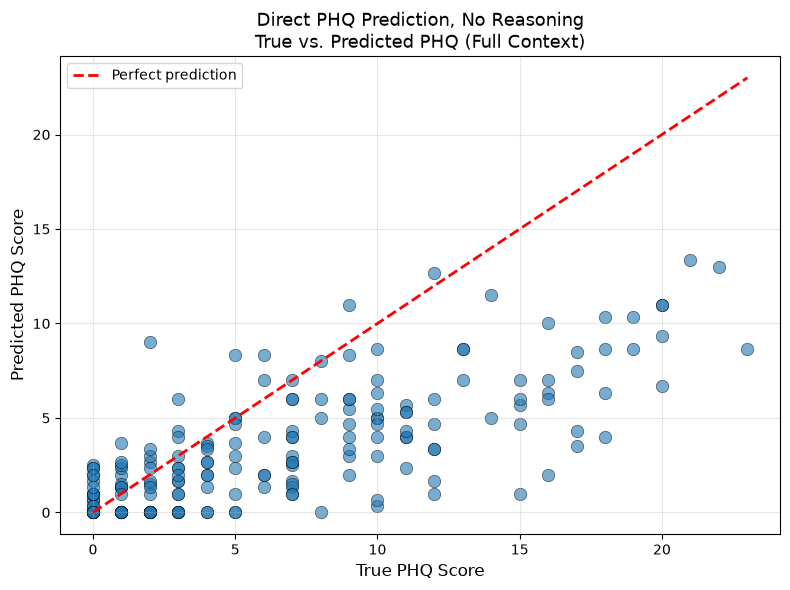

In [15]:
# ============================================================
# 9. PLOT 1:
# TRUE vs. PREDICTED PHQ (FULL CONTEXT)
# ============================================================, Direc 

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(final_mean_over_runs["phq_true"], final_mean_over_runs["phq_pred"], 
           alpha=0.6, s=80, edgecolors='k', linewidth=0.5)

# Perfektlinie
min_val = min(final_mean_over_runs["phq_true"].min(), final_mean_over_runs["phq_pred"].min())
max_val = max(final_mean_over_runs["phq_true"].max(), final_mean_over_runs["phq_pred"].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')

ax.set_xlabel("True PHQ Score", fontsize=12)
ax.set_ylabel("Predicted PHQ Score", fontsize=12)
ax.set_title("Direct PHQ Prediction, No Reasoning\nTrue vs. Predicted PHQ (Full Context)", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

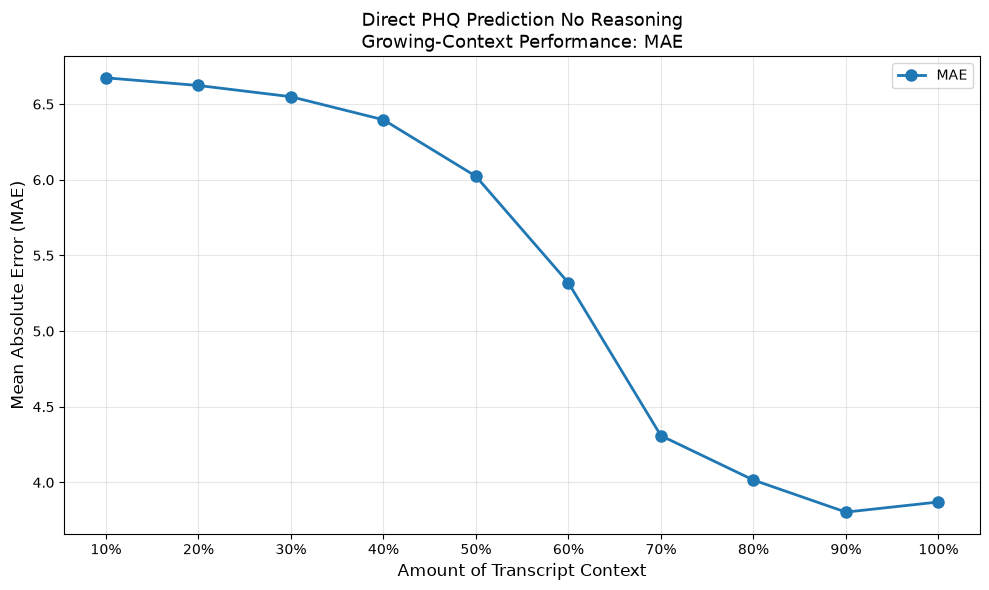

In [16]:
# ============================================================
# 10. PLOT 2:
# GROWING-CONTEXT PERFORMANCE: MAE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    context_metrics["context_bin"].astype(str),
    context_metrics["MAE"],
    marker="o",
    linewidth=2,
    markersize=8,
    label="MAE"
)

ax.set_xlabel("Amount of Transcript Context", fontsize=12)
ax.set_ylabel("Mean Absolute Error (MAE)", fontsize=12)
ax.set_title("Direct PHQ Prediction No Reasoning\nGrowing-Context Performance: MAE", fontsize=13)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

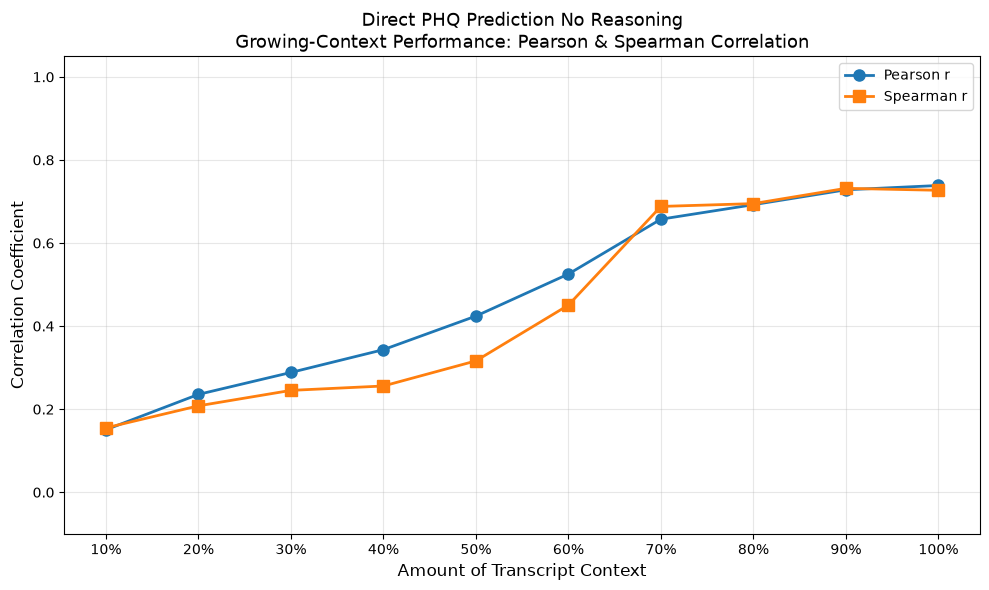

In [17]:
# ============================================================
# 11. PLOT 3:
# GROWING-CONTEXT PERFORMANCE: PEARSON & SPEARMAN
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    context_metrics["context_bin"].astype(str),
    context_metrics["Pearson_r"],
    marker="o",
    linewidth=2,
    markersize=8,
    label="Pearson r"
)

ax.plot(
    context_metrics["context_bin"].astype(str),
    context_metrics["Spearman_r"],
    marker="s",
    linewidth=2,
    markersize=8,
    label="Spearman r"
)

ax.set_xlabel("Amount of Transcript Context", fontsize=12)
ax.set_ylabel("Correlation Coefficient", fontsize=12)
ax.set_title("Direct PHQ Prediction No Reasoning\nGrowing-Context Performance: Pearson & Spearman Correlation", fontsize=13)
ax.grid(alpha=0.3)
ax.legend()
ax.set_ylim([-0.1, 1.05])
plt.tight_layout()
plt.show()